✅ Libraries imported!
✅ Using device: cuda
✅ GPU: Tesla T4
📂 Downloading MNIST (11 MB only!)...


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.63MB/s]


✅ Training: 60000 images
✅ Test: 10000 images
✅ Model on cuda

🚀 Training (5 epochs, fast!)...
Epoch 1/5 | Train: 93.69% | Test: 98.66%
Epoch 2/5 | Train: 98.08% | Test: 98.76%
Epoch 3/5 | Train: 98.61% | Test: 99.04%
Epoch 4/5 | Train: 98.88% | Test: 98.96%
Epoch 5/5 | Train: 99.04% | Test: 98.96%
✅ Training complete!


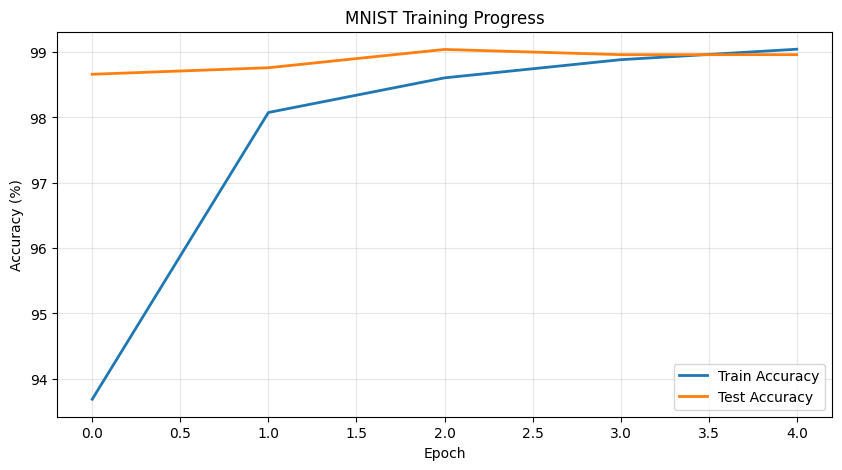


✅ Test Accuracy: 98.96%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



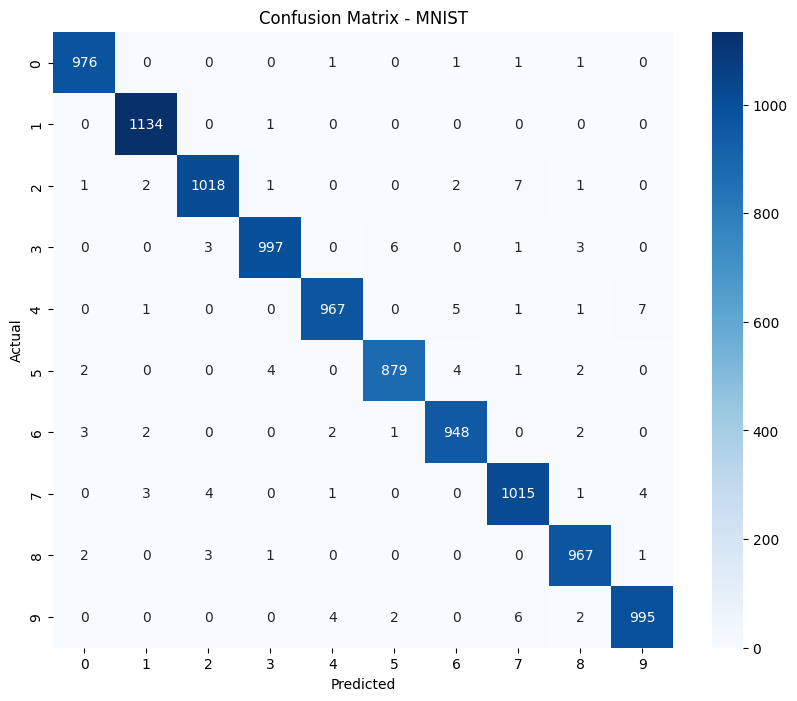

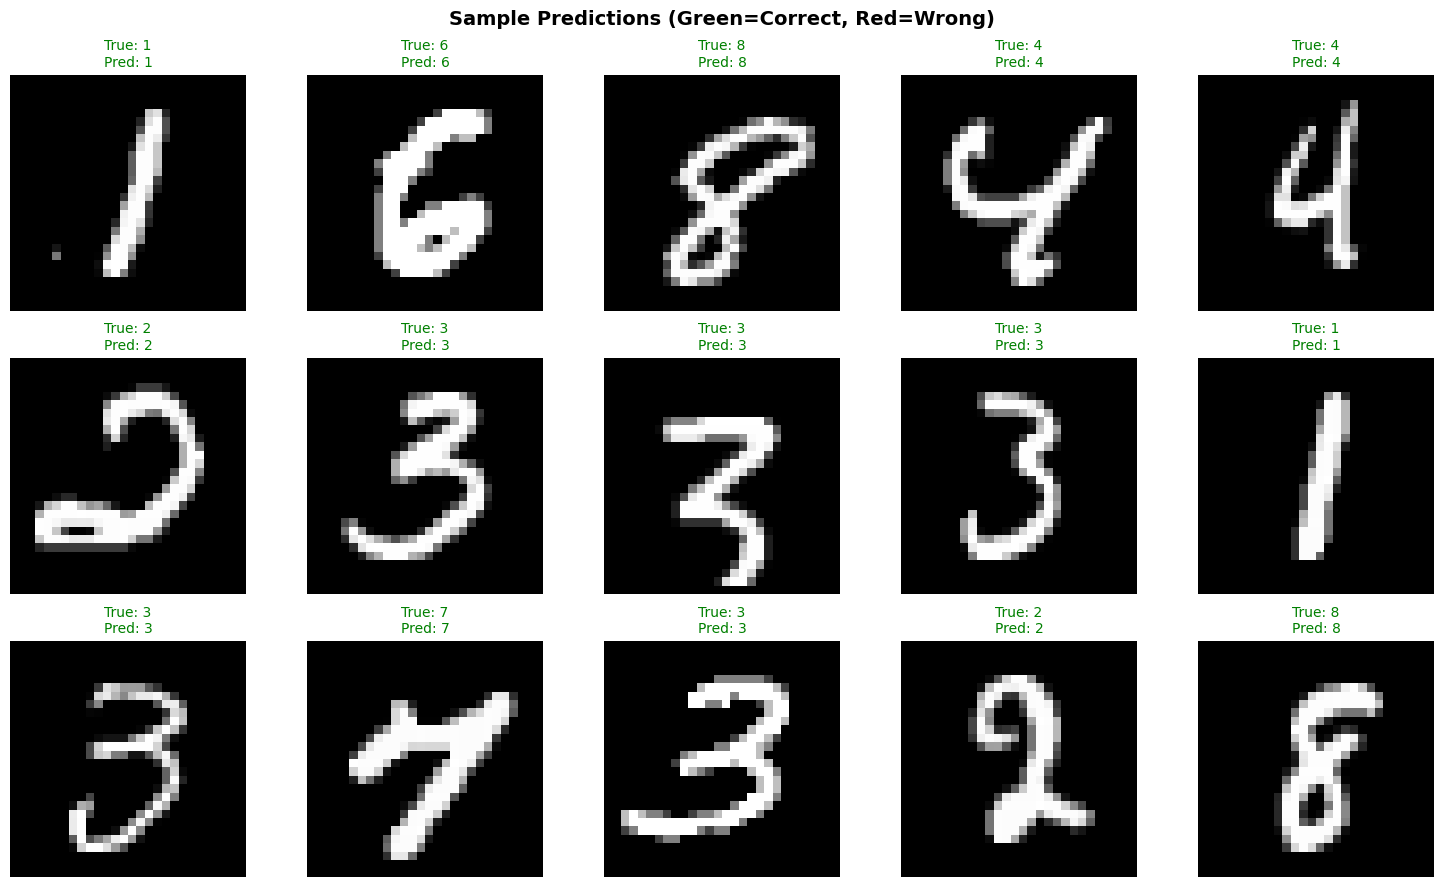

✅ Model saved as 'mnist_cnn.pth'

✅ TASK 2 COMPLETE! (MNIST)
🏆 Test Accuracy: 98.96%


In [1]:
# ============================================
# TASK 2: MNIST DIGIT CLASSIFICATION
# SUPER FAST! With GPU Acceleration
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
if device.type == "cuda":
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# Load MNIST - ONLY 11 MB!
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("📂 Downloading MNIST (11 MB only!)...")
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print(f"✅ Training: {len(trainset)} images")
print(f"✅ Test: {len(testset)} images")

# Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(f"✅ Model on {device}")

# Train - only 5 epochs (fast!)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
train_acc_list = []
test_acc_list = []

print("\n🚀 Training (5 epochs, fast!)...")
for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_acc_list.append(train_acc)

    # Test
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

print("✅ Training complete!")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_acc_list, label='Train Accuracy', linewidth=2)
plt.plot(test_acc_list, label='Test Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('MNIST Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate
model.eval()
all_preds = []
all_labels = []
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"\n✅ Test Accuracy: {test_accuracy:.2f}%")

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MNIST')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Sample predictions
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
indices = np.random.choice(len(testset), 15, replace=False)

for i, idx in enumerate(indices):
    row, col = i // 5, i % 5
    image, label = testset[idx]
    axes[row, col].imshow(image.squeeze(), cmap='gray')

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        _, pred = torch.max(output, 1)

    color = 'green' if label == pred.item() else 'red'
    axes[row, col].set_title(f'True: {label}\nPred: {pred.item()}', color=color, fontsize=10)
    axes[row, col].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Save model
torch.save(model.state_dict(), 'mnist_cnn.pth')
print("✅ Model saved as 'mnist_cnn.pth'")

print("\n" + "="*60)
print("✅ TASK 2 COMPLETE! (MNIST)")
print("="*60)
print(f"🏆 Test Accuracy: {test_accuracy:.2f}%")
print("="*60)